In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

In [3]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 20.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=0.015), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=2.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(Oscillation

In [4]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [5]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [6]:
p = Newtrinos.get_params(experiments)

(N = 20.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [7]:
using Setfield

In [8]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 20.0, m₀ = 0.010125296946109814, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [9]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [10]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58334.8857571943
 60940.87018048108
 56152.7400865542
 68980.28725098167
 76986.31964417448
 85836.19722348073
 86495.39986309822
 81891.46025359601
 77800.10203879118
 72577.4949102797
 65685.64533163633
 59427.66201900168
 53525.163770353145
 48653.68045121829
 44273.83922061495
 39570.03631669868
 33281.97280428219
 34205.246559120715
 25090.73724796007
 19679.07700996586
 14529.648812408814
  9806.248149320325
  6363.636309811431
  6678.697251978775
  3660.826013507638
 17033.732951919046

In [11]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58270.72755889154
 60886.488323236175
 56213.93228024863
 69196.80639963812
 77173.82336142885
 85974.13432043244
 86757.13785426569
 82170.96824687897
 78085.47019136336
 72730.48030711732
 65709.04667092653
 59538.57028290832
 53586.60773056411
 48802.17252928113
 44390.830368152725
 39598.23352796658
 33365.81801395974
 34254.996286700545
 25155.335565227826
 19726.824201087504
 14596.948978915938
  9826.084070735307
  6374.654675864765
  6694.55311995853
  3664.479141463823
 17088.989385690074

In [12]:
using CairoMakie

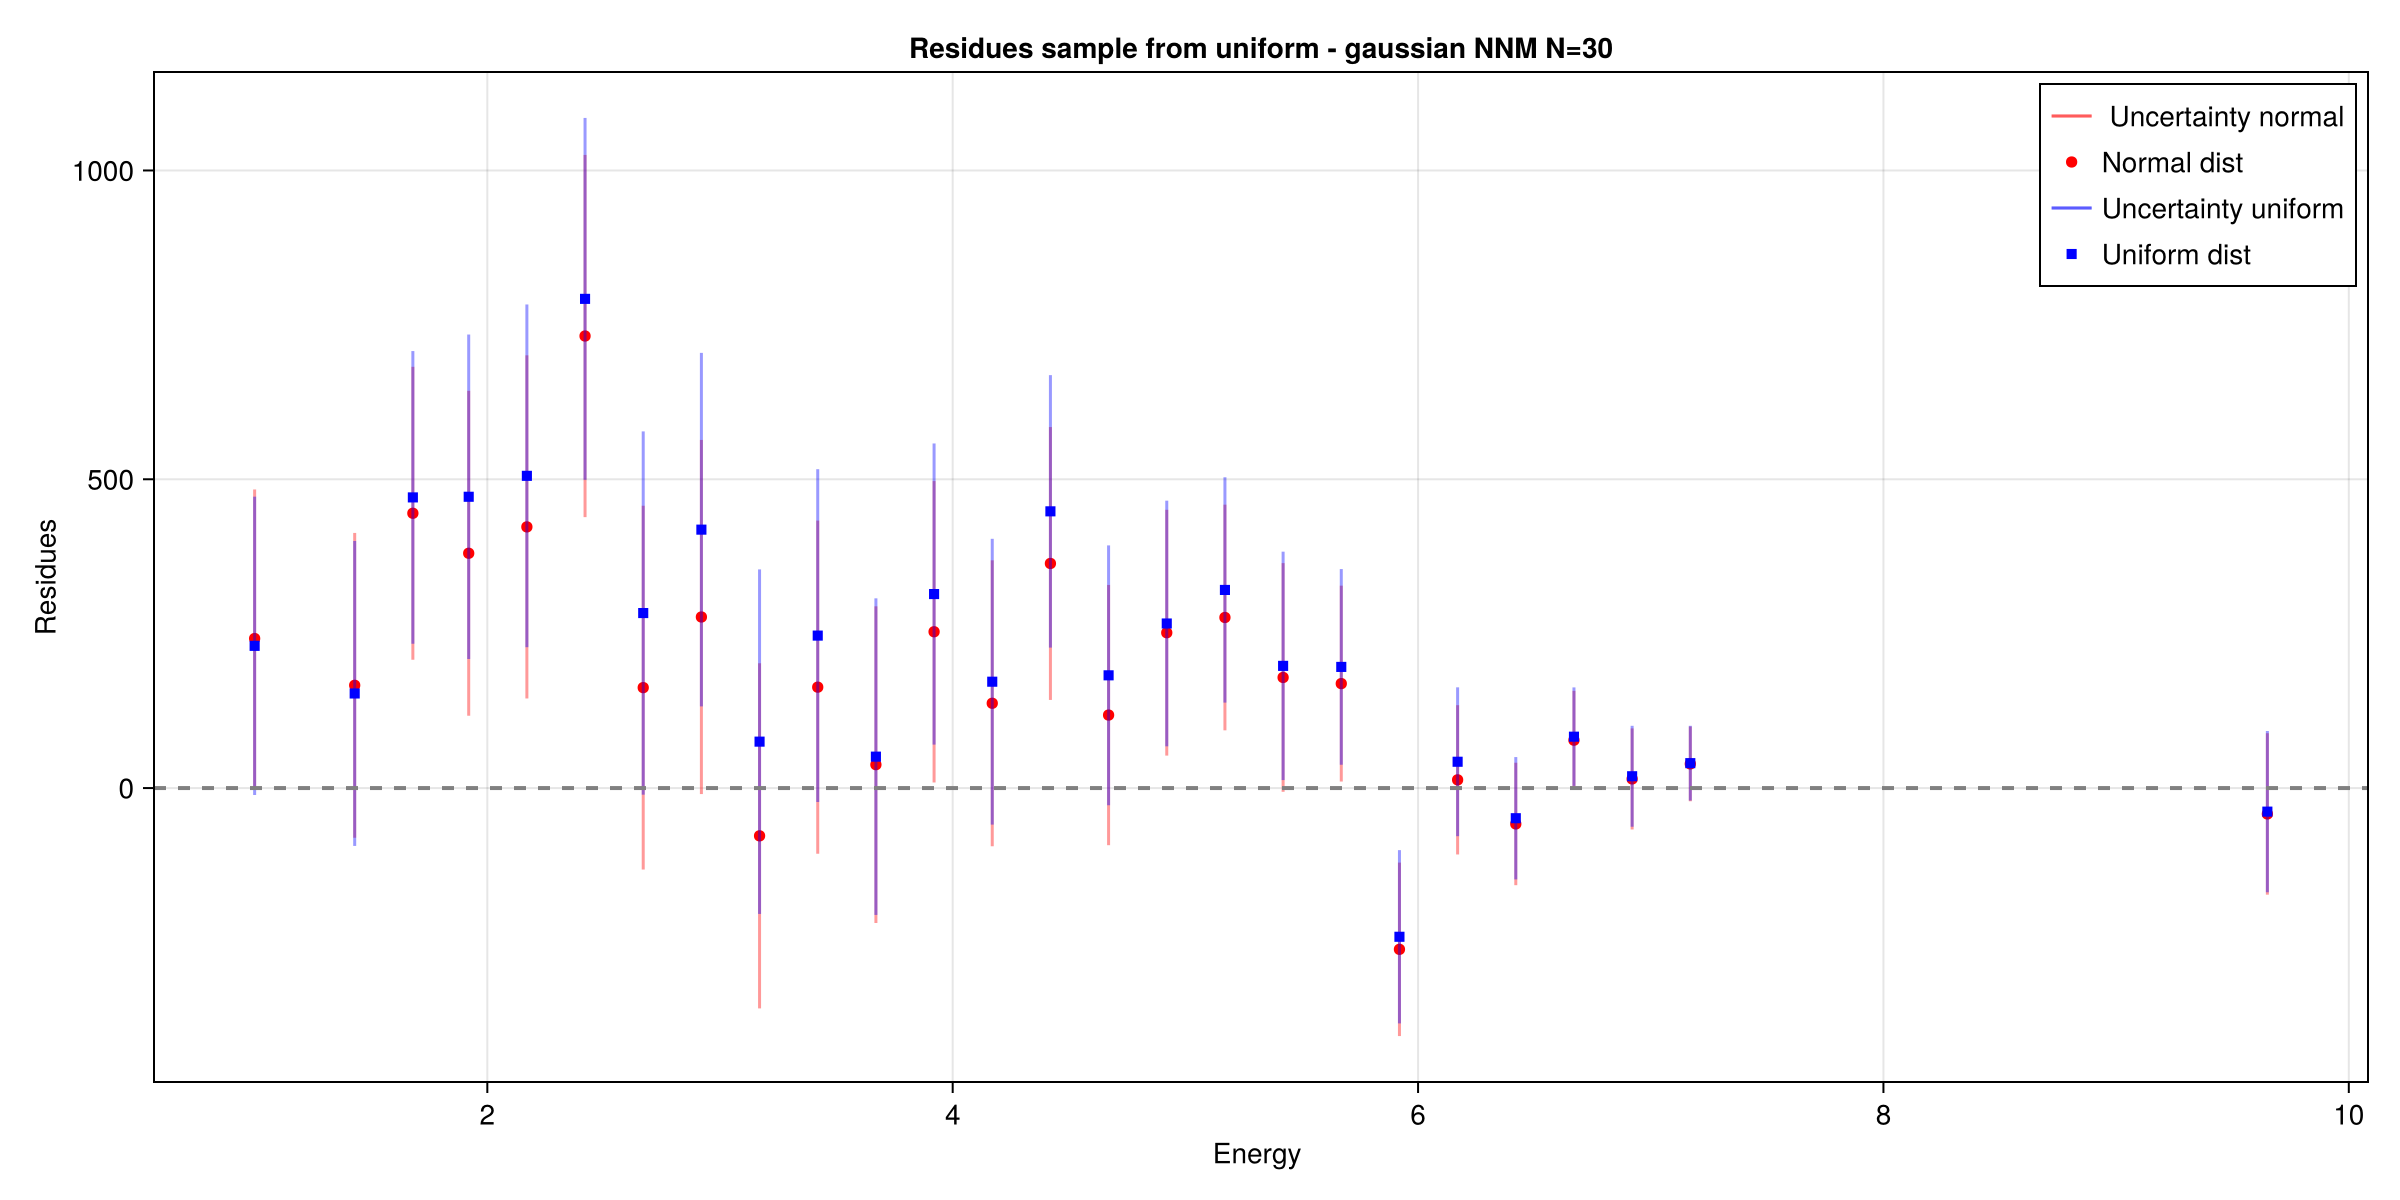

CairoMakie.Screen{IMAGE}


In [13]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=30")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [14]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [15]:

using ProgressMeter
using MeasureBase

In [32]:
function random_sampling(physics, experiments, p, N)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3)))
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm
      p_new_un = @set p.N = N
      p_new_norm = @set p.N = N


      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 2 methods)

In [17]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:02:58


([-172.06104902475408, -170.94105442664605, -172.27043433166233, -171.20736216061294, -172.1058424538338, -172.1062033979397, -172.69562801707625, -171.43012893766743, -170.8573336795301, -173.10666150650633  …  -172.85282746964162, -171.76914629261037, -171.55356823948503, -171.23128591251398, -172.490608873873, -171.049860692606, -172.29833251320088, -172.19083353740618, -171.60526821504797, -172.33562275633474], [-170.6523095322136, -171.3912042036681, -170.12364319228823, -170.71563106932427, -170.58605296570747, -170.65437672674545, -171.4082098268368, -171.31146340431857, -170.743312990004, -170.78477003123763  …  -170.47384586844177, -169.94978042093237, -171.9013729956208, -171.1495154821933, -171.4063832649105, -170.9873608627363, -171.19879736401828, -171.56801666032248, -171.0194515232132, -170.12768990699502])

In [18]:
trial=.-trial # to have the negative log likelihood

([172.06104902475408, 170.94105442664605, 172.27043433166233, 171.20736216061294, 172.1058424538338, 172.1062033979397, 172.69562801707625, 171.43012893766743, 170.8573336795301, 173.10666150650633  …  172.85282746964162, 171.76914629261037, 171.55356823948503, 171.23128591251398, 172.490608873873, 171.049860692606, 172.29833251320088, 172.19083353740618, 171.60526821504797, 172.33562275633474], [170.6523095322136, 171.3912042036681, 170.12364319228823, 170.71563106932427, 170.58605296570747, 170.65437672674545, 171.4082098268368, 171.31146340431857, 170.743312990004, 170.78477003123763  …  170.47384586844177, 169.94978042093237, 171.9013729956208, 171.1495154821933, 171.4063832649105, 170.9873608627363, 171.19879736401828, 171.56801666032248, 171.0194515232132, 170.12768990699502])

In [19]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

170.97193801900488

In [20]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  dayabay= Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

likelihood_SM=-logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

[ Info: Loading dayabay data


168.90003273508322

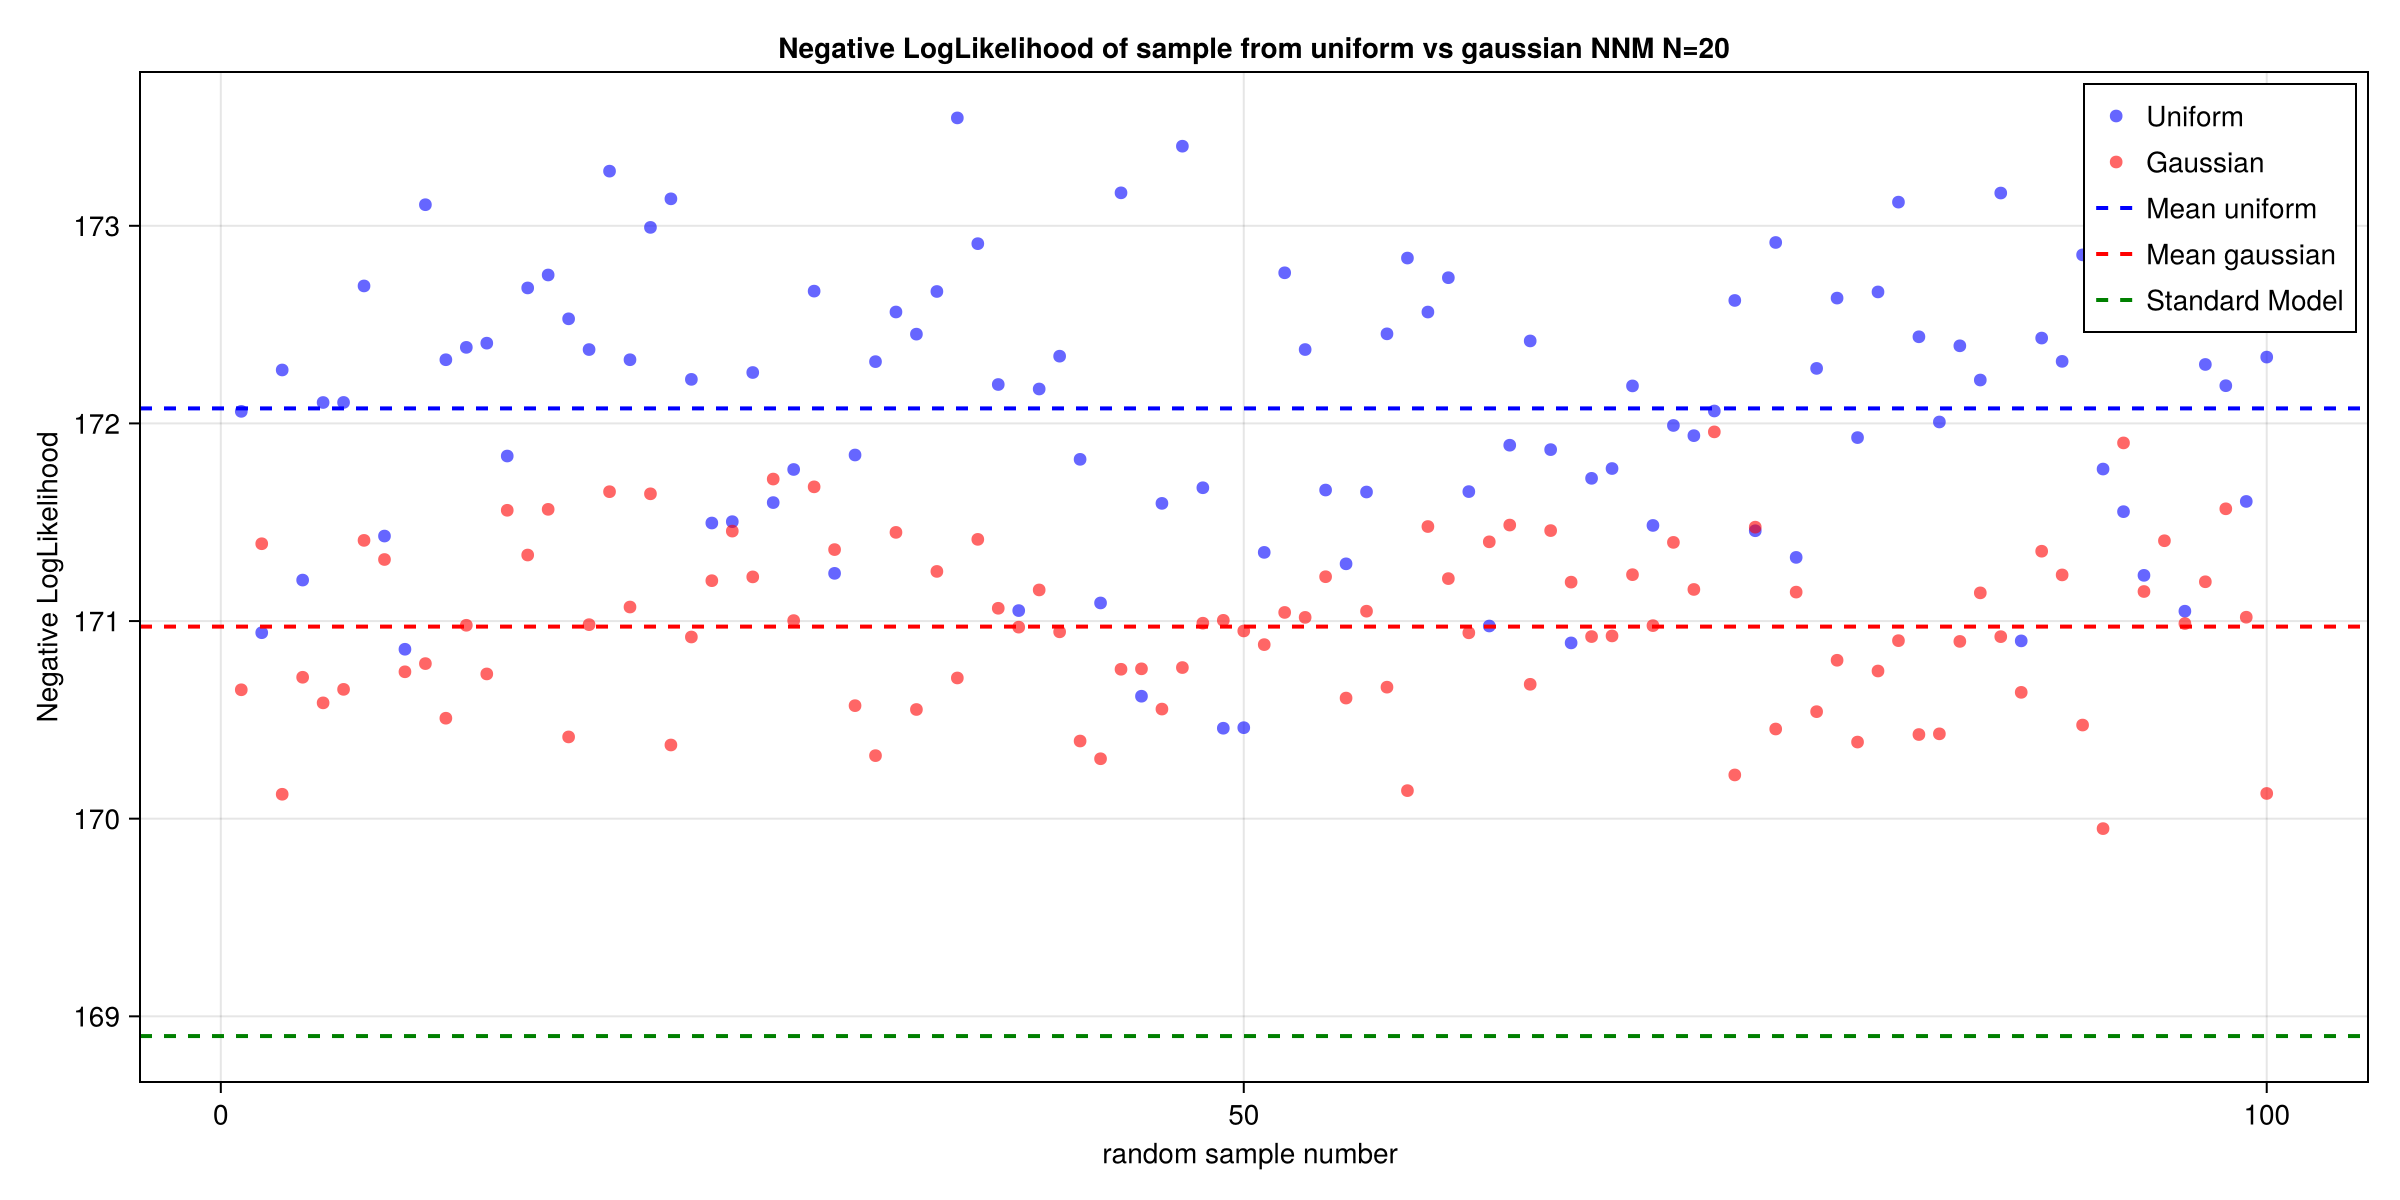

CairoMakie.Screen{IMAGE}


In [21]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NNM N=20")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_samples_NNM_N20_m0=0.1.png", fig)

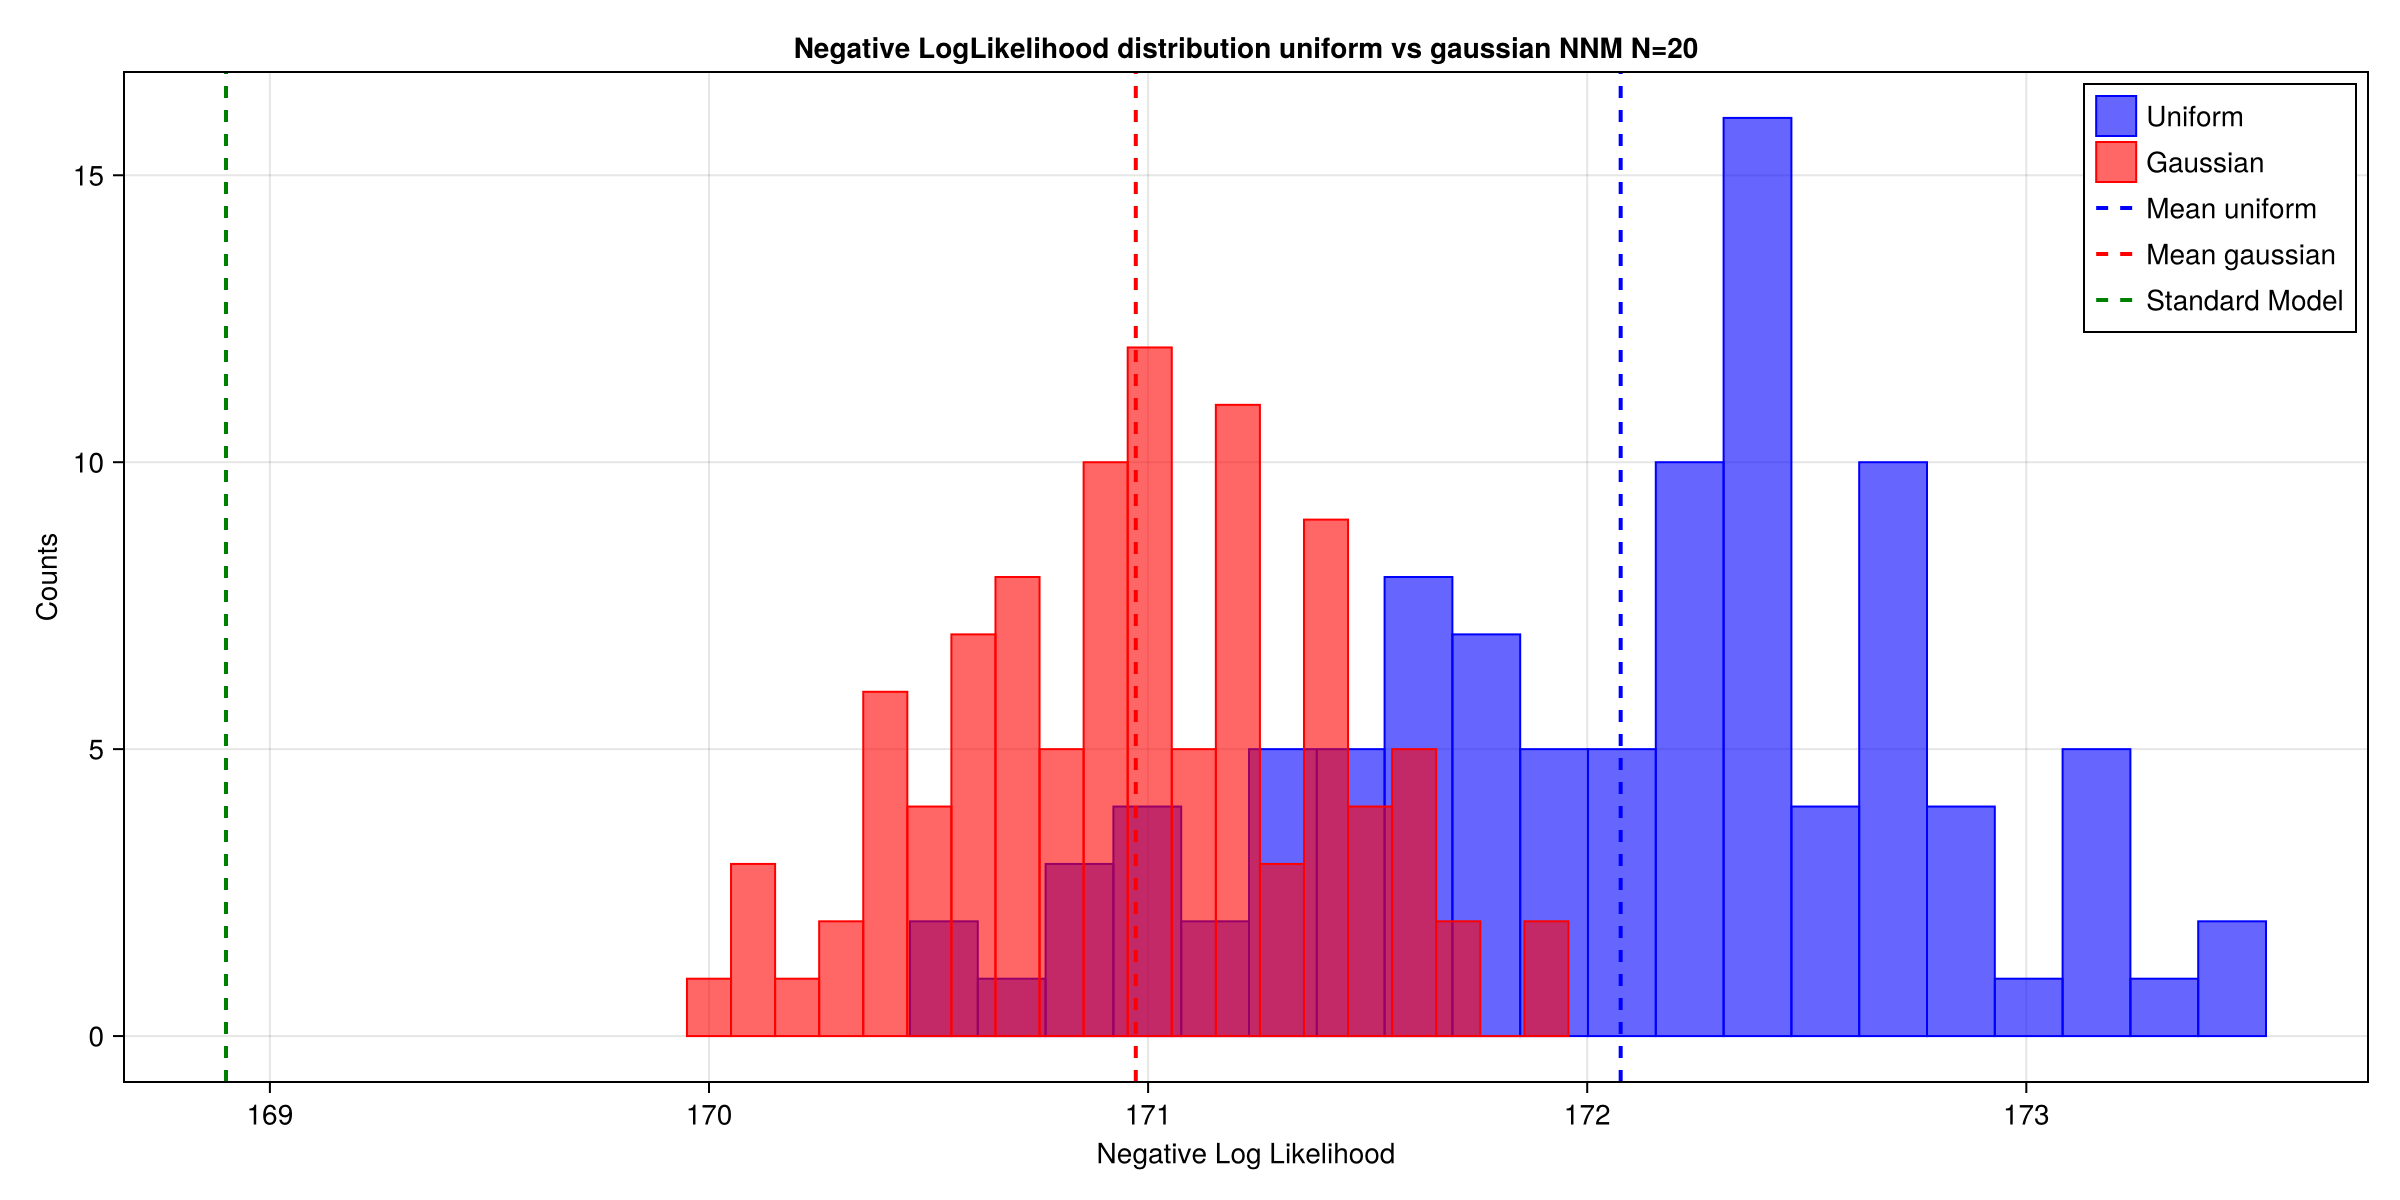

CairoMakie.Screen{IMAGE}


In [22]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NNM N=20")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_N20_m0=0.1.png", fig)

In [44]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    pvalue_un = Float64[]
    pvalue_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

   
    @showprogress for i in 41:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_un= 2*(likelihood_SM-mean_un)
       ratio_norm= 2*(mean_un-mean_norm)

       push!(ratios_un, ratio_un)
       push!(ratios_norm, ratio_norm)

       df = 2   # Difference in number of parameters

       p_value_un = 1 - cdf(Chisq(df), ratio_un)
       p_value_norm = 1 - cdf(Chisq(df), ratio_norm)

        push!(pvalue_un, p_value_un)
        push!(pvalue_norm, p_value_norm)

    end

     
    
    return ratios_un, ratios_norm, pvalue_un, pvalue_norm
end

lik_ratio (generic function with 1 method)

In [ ]:
likelihood_ratios= lik_ratio(45)

Progress: 100%|█████████████████████████████████████████| Time: 0:21:05
Progress:  41%|████████████████▊                        |  ETA: 0:11:47

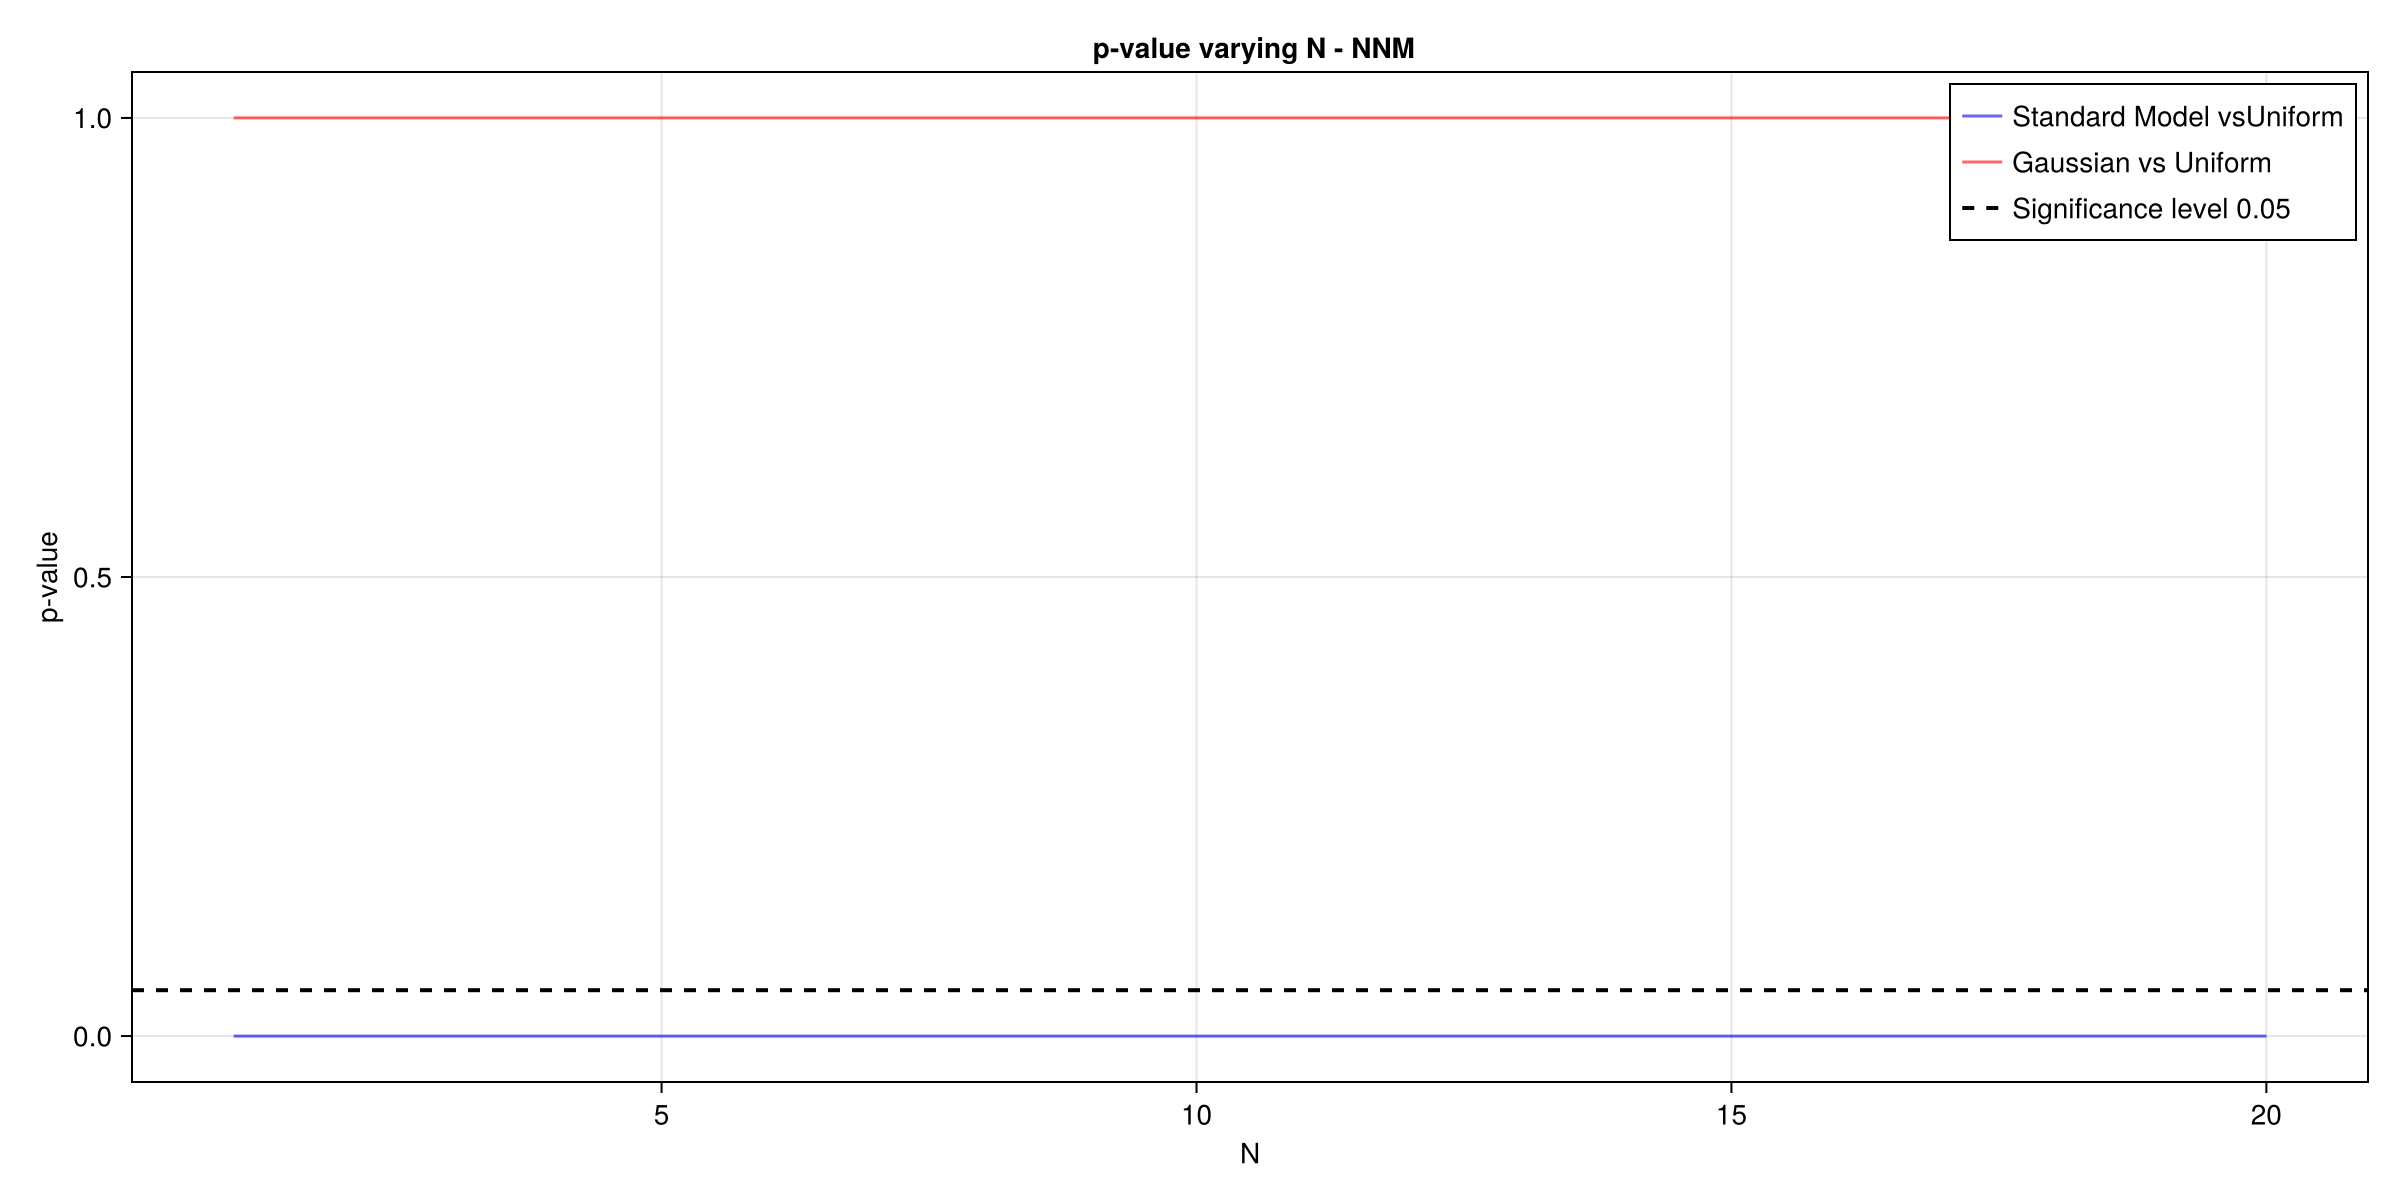

In [ ]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "p-value", 
    title = " p-value varying N - NNM")

x=1:5
lines!(x, likelihood_ratios[:][3], color = (:blue, 0.6),  label = "Standard Model vsUniform")
lines!(x, likelihood_ratios[:][4], color = (:red, 0.6),  label = "Gaussian vs Uniform")

hlines!(0.05, color = :black, linestyle = :dash, linewidth = 2, label = "Significance level 0.05")
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)


save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_r=1_pvalue.png", fig)